In [2]:
import tensorflow as tf
from google.colab import files
uploaded = files.upload()


Saving firstml.zip to firstml.zip


In [3]:
import os
print(os.listdir())

['.config', 'firstml.zip', 'sample_data']


In [4]:
!unzip firstml.zip

Archive:  firstml.zip
   creating: Custom Dataset 1/
   creating: Custom Dataset 1/cups/
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.44.26 (1).jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.44.26.jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.44.27 (1).jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.44.27.jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.44.28 (1).jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.44.28 (2).jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.44.28.jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.45.18.jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.45.24.jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.45.53.jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.48.52.jpeg  
  inflating: Cu

In [5]:
print(os.listdir("Custom Dataset 1"))

['cups', 'handgestures', 'unoflipcards']


In [6]:
import tensorflow as tf
train_dataset =tf.keras.utils.image_dataset_from_directory(
    'Custom Dataset 1',
    validation_split=0.2,
    subset= 'training',
    seed =123,
    image_size=(64,64),
    batch_size=32
)
val_dataset= tf.keras.utils.image_dataset_from_directory(
    'Custom Dataset 1',
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(64,64),
    batch_size=32
)

Found 77 files belonging to 3 classes.
Using 62 files for training.
Found 77 files belonging to 3 classes.
Using 15 files for validation.


In [7]:
print(train_dataset.class_names)

['cups', 'handgestures', 'unoflipcards']


In [8]:
#EPOCHS = 10 , NO DROPOUTS
model1 = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(64,64,3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,443 (6.03 MB)

 Trainable params: 1,581,443 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model1.compile(
    optimizer ='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history1 = model1.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 653ms/step - accuracy: 0.3548 - loss: 3.2169 - val_accuracy: 0.3333 - val_loss: 3.5116
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step - accuracy: 0.3871 - loss: 3.6761 - val_accuracy: 0.2000 - val_loss: 3.3921
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step - accuracy: 0.1774 - loss: 2.5305 - val_accuracy: 0.5333 - val_loss: 1.2242
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step - accuracy: 0.5484 - loss: 1.6201 - val_accuracy: 0.6667 - val_loss: 1.3085
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 745ms/step - accuracy: 0.5645 - loss: 1.6266 - val_accuracy: 0.6667 - val_loss: 1.0621
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step - accuracy: 0.5806 - loss: 1.1456 - val_accuracy: 0.4000 - val_loss: 1.1410
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.6935 - loss: 0.7466 - val_accuracy: 0.4000 - val_loss: 0.9911
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 689ms/step - accuracy: 0.7258 - loss: 0.6904 - val_accuracy: 0.4000 - val_loss: 1.

In [10]:
import tensorflow as tf
from google.colab import files
uploaded = files.upload()


Saving WhatsApp Image 2026-06-12 at 12.09.40.jpeg to WhatsApp Image 2026-06-12 at 12.09.40.jpeg
Saving WhatsApp Image 2026-06-12 at 10.47.40 (2).jpeg to WhatsApp Image 2026-06-12 at 10.47.40 (2).jpeg
Saving WhatsApp Image 2026-06-12 at 10.47.40 (1).jpeg to WhatsApp Image 2026-06-12 at 10.47.40 (1).jpeg
Saving WhatsApp Image 2026-06-12 at 10.47.40.jpeg to WhatsApp Image 2026-06-12 at 10.47.40.jpeg
Saving WhatsApp Image 2026-06-12 at 10.38.07.jpeg to WhatsApp Image 2026-06-12 at 10.38.07.jpeg
Saving WhatsApp Image 2026-06-10 at 22.30.06.jpeg to WhatsApp Image 2026-06-10 at 22.30.06.jpeg


In [11]:
import os
print(os.listdir())

['.config', 'WhatsApp Image 2026-06-12 at 12.09.40.jpeg', 'firstml.zip', 'WhatsApp Image 2026-06-12 at 10.47.40 (1).jpeg', 'WhatsApp Image 2026-06-10 at 22.30.06.jpeg', 'WhatsApp Image 2026-06-12 at 10.47.40.jpeg', 'WhatsApp Image 2026-06-12 at 10.38.07.jpeg', 'Custom Dataset 1', 'WhatsApp Image 2026-06-12 at 10.47.40 (2).jpeg', 'sample_data']


In [12]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

img = load_img('WhatsApp Image 2026-06-10 at 22.30.06.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model1.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# the image is not in the dataset but is a pretty similar one, different background, model did good
# correct prediction


img = load_img('WhatsApp Image 2026-06-12 at 10.38.07.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model1.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image but very similar background and same cup pattern
# correct prediction

img = load_img('WhatsApp Image 2026-06-12 at 10.47.40.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model1.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# a bright red cup, none like in dataset, model is picking a random probability
# wrong prediction
# epochs =10, wrong prediction by a very large margin, i don't know why its not more equal
# Predicted: unoflipcards


img = load_img('WhatsApp Image 2026-06-12 at 10.47.40 (1).jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model1.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image for hand gestures, but with 2 hands this time, unlike in dataset
# wrong prediction

img = load_img('WhatsApp Image 2026-06-12 at 10.47.40 (2).jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model1.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image of unoflipcards
# correct prediction

img = load_img('WhatsApp Image 2026-06-12 at 12.09.40.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model1.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image of hand gestures
# wrong prediction (by a large margin, i don't understand because this one was pretty similar still)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
[[0.1227075  0.77251506 0.10477743]]
Predicted: handgestures
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.5698142  0.04822625 0.38195947]]
Predicted: cups
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.04782361 0.06533054 0.8868458 ]]
Predicted: unoflipcards
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.21154931 0.12325461 0.66519606]]
Predicted: unoflipcards
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
[[0.17681988 0.10185004 0.7213301 ]]
Predicted: unoflipcards
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.13901739 0.05236933 0.80861324]]
Predicted: unoflipcards


In [13]:
#EPOCHS = 20 ,  DROPOUTS

model2 = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(64,64,3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3, activation='softmax')
])
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,443 (6.03 MB)

 Trainable params: 1,581,443 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model2.compile(
    optimizer ='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history2 = model2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20
)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 748ms/step - accuracy: 0.2258 - loss: 2.3232 - val_accuracy: 0.3333 - val_loss: 3.0970
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step - accuracy: 0.3065 - loss: 3.2984 - val_accuracy: 0.3333 - val_loss: 1.2608
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step - accuracy: 0.4516 - loss: 2.8842 - val_accuracy: 0.5333 - val_loss: 0.8539
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.3548 - loss: 1.9832 - val_accuracy: 0.3333 - val_loss: 1.3283
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 780ms/step - accuracy: 0.4839 - loss: 1.2648 - val_accuracy: 0.4667 - val_loss: 0.9579
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 741ms/step - accuracy: 0.5161 - loss: 1.2656 - val_accuracy: 0.6000 - val_loss: 0.8951
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step - accuracy: 0.4839 - loss: 1.2839 - val_accuracy: 0.6000 - val_loss: 0.8837
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step - accuracy: 0.4516 - loss: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.

In [15]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

img = load_img('WhatsApp Image 2026-06-10 at 22.30.06.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# the image is not in the dataset but is a pretty similar one, different background, model did good
# correct prediction


img = load_img('WhatsApp Image 2026-06-12 at 10.38.07.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image but very similar background and same cup pattern
# correct prediction

img = load_img('WhatsApp Image 2026-06-12 at 10.47.40.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# a bright red cup, none like in dataset, model is picking a random probability
# wrong prediction
# epochs =20, wrong prediction by a very large margin, i don't know why its not more equal
# Predicted: unoflipcards


img = load_img('WhatsApp Image 2026-06-12 at 10.47.40 (1).jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image for hand gestures, but with 2 hands this time, unlike in dataset
# wrong prediction

img = load_img('WhatsApp Image 2026-06-12 at 10.47.40 (2).jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image of unoflipcards
# wrong prediction

img = load_img('WhatsApp Image 2026-06-12 at 12.09.40.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image of hand gestures
# wrong prediction (by a large margin, i don't understand because this one was pretty similar still)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
[[0.16653952 0.7661664  0.06729407]]
Predicted: handgestures
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
[[0.800122   0.11974232 0.08013562]]
Predicted: cups
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
[[0.22019215 0.5697395  0.21006833]]
Predicted: handgestures
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[0.553306   0.27315825 0.17353581]]
Predicted: cups
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
[[0.38320416 0.46146086 0.15533498]]
Predicted: handgestures
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[[0.41374967 0.28164414 0.30460617]]
Predicted: cups


In [19]:
#EPOCHS = 20 , NO DROPOUTS

model3 = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(64,64,3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])
model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,443 (6.03 MB)

 Trainable params: 1,581,443 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model3.compile(
    optimizer ='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history3 = model3.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20
)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 863ms/step - accuracy: 0.3387 - loss: 1.8290 - val_accuracy: 0.4667 - val_loss: 3.8971
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 592ms/step - accuracy: 0.2903 - loss: 4.9610 - val_accuracy: 0.2000 - val_loss: 2.1821
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5000 - loss: 1.5312 - val_accuracy: 0.3333 - val_loss: 1.5062
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 606ms/step - accuracy: 0.3387 - loss: 1.6026 - val_accuracy: 0.7333 - val_loss: 1.0388
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step - accuracy: 0.4516 - loss: 1.2107 - val_accuracy: 0.2000 - val_loss: 1.4916
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step - accuracy: 0.4677 - loss: 1.1174 - val_accuracy: 0.7333 - val_loss: 0.7927
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step - accuracy: 0.8065 - loss: 0.6490 - val_accuracy: 0.6000 - val_loss: 0.9499
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step - accuracy: 0.7258 - loss: 0.6403 - val_accuracy: 0.5333 - val_loss: 1.

In [21]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

img = load_img('WhatsApp Image 2026-06-10 at 22.30.06.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# the image is not in the dataset but is a pretty similar one, different background, model did good
# correct prediction


img = load_img('WhatsApp Image 2026-06-12 at 10.38.07.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image but very similar background and same cup pattern
# correct prediction

img = load_img('WhatsApp Image 2026-06-12 at 10.47.40.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# a bright red cup, none like in dataset, model is picking a random probability
# wrong prediction
# epochs =20, wrong prediction by a very large margin, i don't know why its not more equal
# Predicted: unoflipcards


img = load_img('WhatsApp Image 2026-06-12 at 10.47.40 (1).jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image for hand gestures, but with 2 hands this time, unlike in dataset
# wrong prediction

img = load_img('WhatsApp Image 2026-06-12 at 10.47.40 (2).jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image of unoflipcards
# wrong prediction

img = load_img('WhatsApp Image 2026-06-12 at 12.09.40.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image of hand gestures
# wrong prediction (by a large margin, i don't understand because this one was pretty similar still)

#all last 3 images predicted cups this time as the wrong prediction, unlike when epochs were 10 and no dropouts, maybe it is because cups are the first class

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[0.16653952 0.7661664  0.06729407]]
Predicted: handgestures
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
[[0.800122   0.11974232 0.08013562]]
Predicted: cups
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.22019215 0.5697395  0.21006833]]
Predicted: handgestures
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[0.553306   0.27315825 0.17353581]]
Predicted: cups
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
[[0.38320416 0.46146086 0.15533498]]
Predicted: handgestures
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[0.41374967 0.28164414 0.30460617]]
Predicted: cups


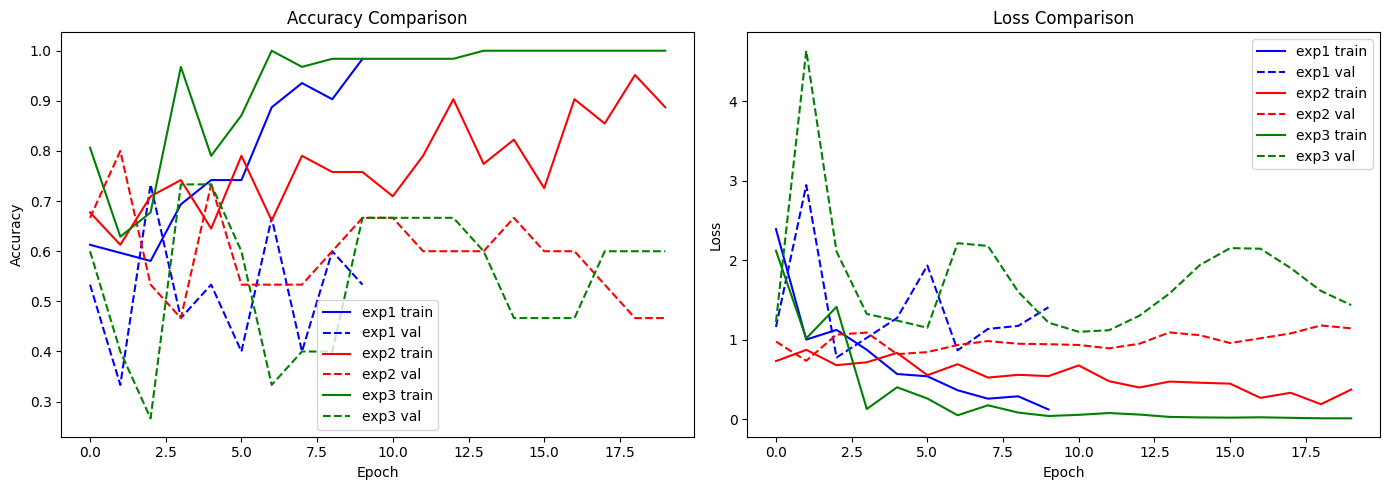

In [44]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history1.history['accuracy'], label='exp1 train', color='blue')
axes[0].plot(history1.history['val_accuracy'], label='exp1 val', color='blue', linestyle='dashed')
axes[0].plot(history2.history['accuracy'], label='exp2 train', color='red')
axes[0].plot(history2.history['val_accuracy'], label='exp2 val', color='red', linestyle='dashed')
axes[0].plot(history3.history['accuracy'], label='exp3 train', color='green')
axes[0].plot(history3.history['val_accuracy'], label='exp3 val', color='green', linestyle='dashed')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss plot
axes[1].plot(history1.history['loss'], label='exp1 train', color='blue')
axes[1].plot(history1.history['val_loss'], label='exp1 val', color='blue', linestyle='dashed')
axes[1].plot(history2.history['loss'], label='exp2 train', color='red')
axes[1].plot(history2.history['val_loss'], label='exp2 val', color='red', linestyle='dashed')
axes[1].plot(history3.history['loss'], label='exp3 train', color='green')
axes[1].plot(history3.history['val_loss'], label='exp3 val', color='green', linestyle='dashed')
axes[1].set_title('Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('experiment_results.png')  # saves the plot
plt.show()

In [27]:
#HIGH LEARNING RATE
model4 = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(64, 64, 3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history4 = model4.fit(train_dataset,
                      validation_data=val_dataset,
                      epochs=10)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 738ms/step - accuracy: 0.3387 - loss: 2116.0022 - val_accuracy: 0.2000 - val_loss: 3353.3408
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step - accuracy: 0.2581 - loss: 2673.6633 - val_accuracy: 0.3333 - val_loss: 337.7064
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step - accuracy: 0.3226 - loss: 900.1716 - val_accuracy: 0.4667 - val_loss: 845.9171
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step - accuracy: 0.3387 - loss: 1103.3207 - val_accuracy: 0.2000 - val_loss: 601.8698
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 844ms/step - accuracy: 0.4032 - loss: 328.7991 - val_accuracy: 0.3333 - val_loss: 791.4144
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.4677 - loss: 337.6280 - val_accuracy: 0.2000 - val_loss: 90.6919
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step - accuracy: 0.3871 - loss: 39.6500 - val_accuracy: 0.4667 - val_loss: 1.0561
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step - accuracy: 0.4194 - loss: 3.0094 - val_acc

In [28]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

img = load_img('WhatsApp Image 2026-06-10 at 22.30.06.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# the image is not in the dataset but is a pretty similar one, different background, model did good
# correct prediction


img = load_img('WhatsApp Image 2026-06-12 at 10.38.07.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image but very similar background and same cup pattern
# correct prediction

img = load_img('WhatsApp Image 2026-06-12 at 10.47.40.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# a bright red cup, none like in dataset, model is picking a random probability
# wrong prediction
# Predicted: handgestures


img = load_img('WhatsApp Image 2026-06-12 at 10.47.40 (1).jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image for hand gestures, but with 2 hands this time, unlike in dataset
# wrong prediction

img = load_img('WhatsApp Image 2026-06-12 at 10.47.40 (2).jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image of unoflipcards
# wrong prediction

img = load_img('WhatsApp Image 2026-06-12 at 12.09.40.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image of hand gestures
# wrong prediction

#all the wrong predictions had almost equal probability of result, at high learning rate model jumps wildly and we see unstable training

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.16653952 0.7661664  0.06729407]]
Predicted: handgestures
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[0.800122   0.11974232 0.08013562]]
Predicted: cups
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.22019215 0.5697395  0.21006833]]
Predicted: handgestures
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[0.553306   0.27315825 0.17353581]]
Predicted: cups
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[0.38320416 0.46146086 0.15533498]]
Predicted: handgestures
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[0.41374967 0.28164414 0.30460617]]
Predicted: cups


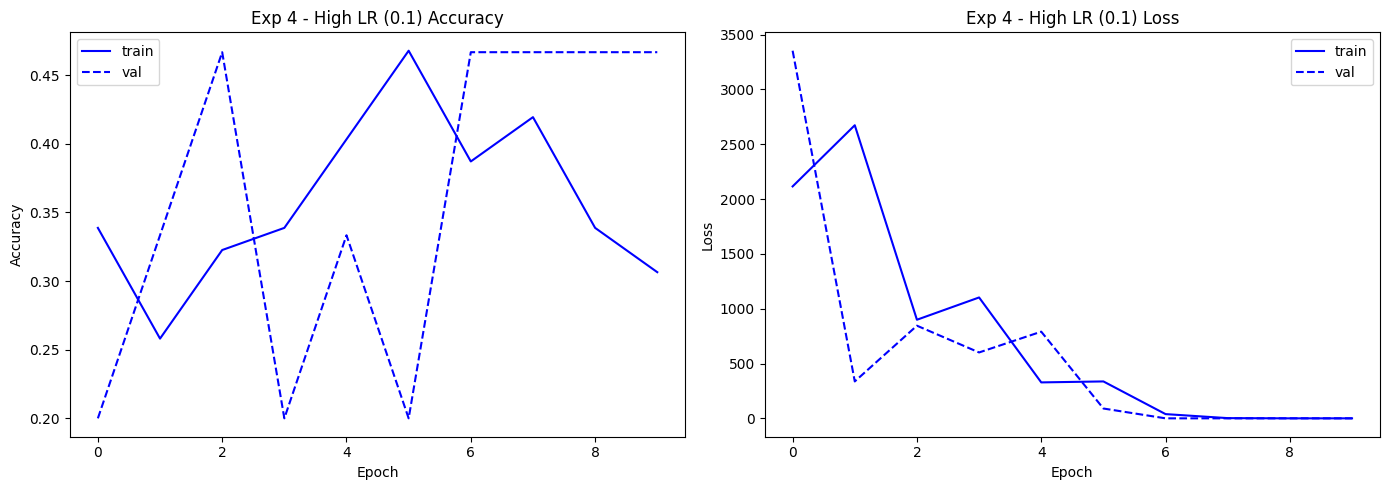

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history4.history['accuracy'], label='train', color='blue')
axes[0].plot(history4.history['val_accuracy'], label='val', color='blue', linestyle='dashed')
axes[0].set_title('Exp 4 - High LR (0.1) Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history4.history['loss'], label='train', color='blue')
axes[1].plot(history4.history['val_loss'], label='val', color='blue', linestyle='dashed')
axes[1].set_title('Exp 4 - High LR (0.1) Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('high_lr_experiment.png')
plt.show()